In [1]:
#pip install pm4py
import os
os.getcwd()

'C:\\Users\\obami\\Documents\\Python_Pra\\Thesis_PPM_2024-25'

In [1]:
#import data
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import joblib
import matplotlib.pyplot as plt

#model 
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input, Embedding
from tensorflow.saved_model import save

# Modelling

In [2]:
##prefix data

train_prefix_trace_encoded = np.load("ptc_train_prefix.npy")
val_prefix_trace_encoded = np.load("ptc_val_prefix.npy")
test_prefix_trace_encoded = np.load("ptc_test_prefix.npy")

##probability data
train_dfg_probability = pd.read_csv("ptc_train_dfg_probability.csv")
val_dfg_probability = pd.read_csv("ptc_val_dfg_probability.csv")
test_dfg_probability = pd.read_csv("ptc_test_dfg_probability.csv")

#target
train_target_encoded = np.load("ptc_train_target.npy")
val_target_encoded = np.load("ptc_val_target.npy")
test_target_encoded = np.load("ptc_test_target.npy")

#encoder
label_encoder = joblib.load('ptc_label_encoder.joblib')

#original data
train_target = pd.read_csv("ptc_train_target_org.csv")
test_target = pd.read_csv("ptc_test_target_org.csv")

## Prefix Model

In [3]:
# Example input shape: (timesteps, features)
features = train_prefix_trace_encoded.shape[1]
sequence = train_prefix_trace_encoded.shape[2]
output = train_target_encoded.shape[1]
prefix_model = Sequential()

#LSTM Layears
prefix_model.add(LSTM(400, return_sequences=False, input_shape=(features,sequence)))

# Output layer (classification)
prefix_model.add(Dense(output, activation='softmax'))
prefix_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['categorical_accuracy'])
prefix_model.summary()

C:\Users\obami\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 400)            │       691,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 31)             │        12,431 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 703,631 (2.68 MB)

 Trainable params: 703,631 (2.68 MB)

 Non-trainable params: 0 (0.00 B)

In [4]:
#  Train Model
history = prefix_model.fit(train_prefix_trace_encoded, train_target_encoded, epochs=100, batch_size=100, 
                           validation_data = (val_prefix_trace_encoded, val_target_encoded), verbose=0)

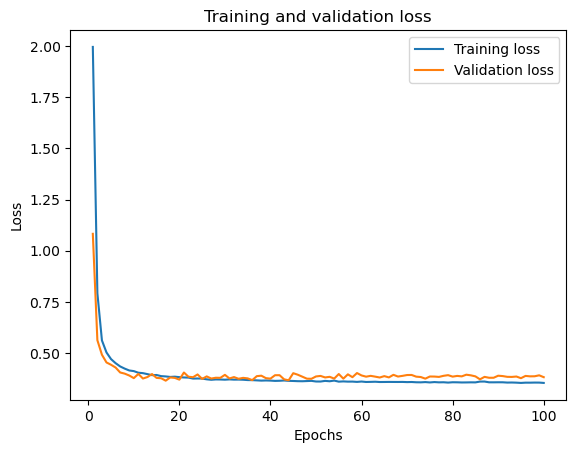

In [5]:
train_loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(train_loss) + 1)

plt.plot(epochs, train_loss, label='Training loss')
plt.plot(epochs, val_loss, label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [6]:
prefix_model.evaluate(test_prefix_trace_encoded,test_target_encoded)

199/199 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - categorical_accuracy: 0.8549 - loss: 0.4551


[0.4668709933757782, 0.8619227409362793]

## Check Predictions

In [7]:
from predictions import single_input_prediction, multi_input_prediction

In [8]:
actual_label = train_target["activity"]
single_input_prediction(prefix_model, train_prefix_trace_encoded, label_encoder)

328/328 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step


array(['permit submitted by employee',
       'permit approved by administration',
       'permit final_approved by supervisor', ..., 'request payment',
       'payment handled', 'zos'], dtype=object)

In [9]:
actual_label = test_target["activity"]
test_predictions = single_input_prediction(prefix_model, test_prefix_trace_encoded, label_encoder)
#test_predictions = single_input_prediction(prefix_model, test_prefix_trace_encoded, label_encoder,actual_label,"test")

199/199 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step


In [10]:
#save model
prefix_model.save("ptc_prefix_model.keras")

## DFG Model Only

In [11]:
from tensorflow.keras.layers import Dropout

dfg_model = Sequential()

#Layers
dfg_model.add(Dense(100,activation="relu", input_shape=(train_dfg_probability.shape[1],)))


# Output layer (classification)
dfg_model.add(Dense(train_target_encoded.shape[1], activation='softmax'))
dfg_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['categorical_accuracy'])
dfg_model.summary()

C:\Users\obami\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 100)            │         3,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 31)             │         3,131 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,331 (24.73 KB)

 Trainable params: 6,331 (24.73 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# Train Model
history = dfg_model.fit(train_dfg_probability, train_target_encoded, epochs=100, batch_size=100, 
                        validation_data = (val_dfg_probability, val_target_encoded), verbose=0)

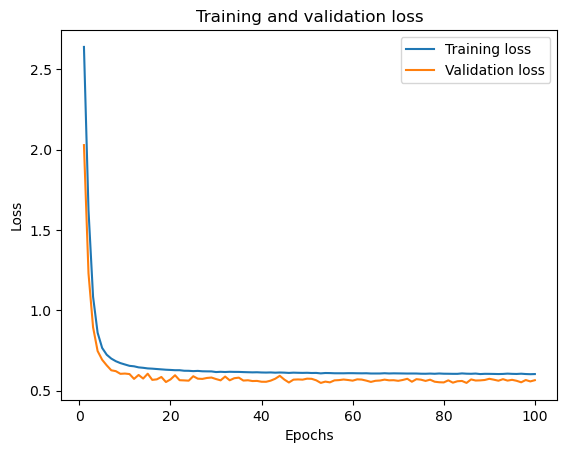

In [13]:
import matplotlib.pyplot as plt
train_loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(train_loss) + 1)

plt.plot(epochs, train_loss, label='Training loss')
plt.plot(epochs, val_loss, label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [15]:
actual_label = train_target["activity"]
single_input_prediction(dfg_model, train_dfg_probability, label_encoder)

328/328 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


array(['permit submitted by employee',
       'permit approved by administration',
       'permit final_approved by supervisor', ..., 'request payment',
       'payment handled', 'zos'], dtype=object)

In [16]:
actual_label = test_target["activity"]
single_input_prediction(dfg_model, test_dfg_probability, label_encoder)

199/199 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


array(['permit submitted by employee',
       'permit approved by administration',
       'permit final_approved by supervisor', ..., 'request payment',
       'payment handled', 'zos'], dtype=object)

In [17]:
#save model
dfg_model.save("ptc_dfg_model.keras")

## Prefix DFG Model_1

In [18]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Concatenate

#prefix input
prefix_features = train_prefix_trace_encoded.shape[1]
prefix_sequence = train_prefix_trace_encoded.shape[2]

prefix_input = Input(shape=(prefix_features,prefix_sequence),name="prefix")
prefix_model = LSTM(20, return_sequences=False, name="prefix_layer_1")(prefix_input)

# dfg input
dfg_features = train_dfg_probability.shape[1]

dfg_input = Input(shape=(dfg_features,),name="dfg")
dfg_model = Dense(10, activation="relu", name="dfg_layer_1")(dfg_input)


#Concatenate Layers
concatenated = Concatenate(name='Concatenated_Layer')([prefix_model, dfg_model])

# Output layer (classification)
output = train_target_encoded.shape[1]
output_layer = Dense(output,activation='softmax')(concatenated)

#Define model
prefix_dfg_model = Model(inputs=[prefix_input,dfg_input],outputs=output_layer)
prefix_dfg_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['categorical_accuracy'])
prefix_dfg_model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ prefix (InputLayer) │ (None, 22, 31)    │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dfg (InputLayer)    │ (None, 31)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ prefix_layer_1      │ (None, 20)        │      4,160 │ prefix[0][0]      │
│ (LSTM)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dfg_layer_1 (Dense) │ (None, 10)        │        320 │ dfg[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Concatenated_Layer  │ (None, 30)        │          0 │ prefix_layer_1[0… │
│ (Concatenate)       │                   │            │ dfg_layer_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 31)        │        961 │ Concatenated_Lay… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,441 (21.25 KB)

 Trainable params: 5,441 (21.25 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
history = prefix_dfg_model.fit([train_prefix_trace_encoded,train_dfg_probability], train_target_encoded, epochs=100, batch_size=100, 
                               validation_data = ([val_prefix_trace_encoded,val_dfg_probability], val_target_encoded), verbose=0)

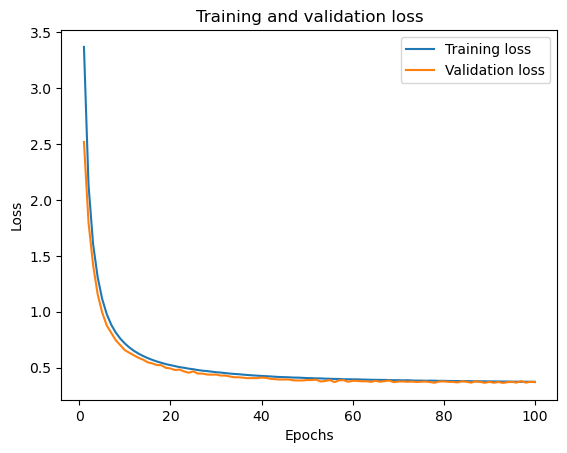

In [20]:
import matplotlib.pyplot as plt
train_loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(train_loss) + 1)

plt.plot(epochs, train_loss, label='Training loss')
plt.plot(epochs, val_loss, label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [21]:
actual_label = train_target["activity"]
multi_input_prediction(prefix_dfg_model,train_prefix_trace_encoded, train_dfg_probability, label_encoder)

328/328 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step


array(['permit submitted by employee',
       'permit approved by administration',
       'permit final_approved by supervisor', ..., 'request payment',
       'payment handled', 'zos'], dtype=object)

In [22]:
actual_label = test_target["activity"]
multi_input_prediction(prefix_dfg_model,test_prefix_trace_encoded, test_dfg_probability, label_encoder)

199/199 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


array(['permit submitted by employee',
       'permit approved by administration',
       'permit final_approved by supervisor', ..., 'request payment',
       'payment handled', 'zos'], dtype=object)

In [23]:
#save model
prefix_dfg_model.save("ptc_prefix_dfg_model.keras")

## Prefix_DFG Model_2

In [24]:
#prefix input
prefix_features = train_prefix_trace_encoded.shape[1]
prefix_sequence = train_prefix_trace_encoded.shape[2]

#prefix layer
prefix_input = Input(shape=(prefix_features,prefix_sequence),name="prefix")
prefix_model = LSTM(20, return_sequences=False, name="prefix_layer_1")(prefix_input)

#dfg input
dfg_features = train_dfg_probability.shape[1]
dfg_input = Input(shape=(dfg_features,),name="dfg")

# combine prefix with dfg input
combined_input = Concatenate(name="prefix_dfg_input")([prefix_model,dfg_input])
prefix_dfg_layer = Dense(20, activation="relu", name="dfg_layer_1")(combined_input)

# Output layer (classification)
output = train_target_encoded.shape[1]
output_layer = Dense(output,activation='softmax')(prefix_dfg_layer)

#Define model
prefix_dfg_model_2 = Model(inputs=[prefix_input,dfg_input],outputs=output_layer)
prefix_dfg_model_2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['categorical_accuracy'])
prefix_dfg_model_2.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ prefix (InputLayer) │ (None, 22, 31)    │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ prefix_layer_1      │ (None, 20)        │      4,160 │ prefix[0][0]      │
│ (LSTM)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dfg (InputLayer)    │ (None, 31)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ prefix_dfg_input    │ (None, 51)        │          0 │ prefix_layer_1[0… │
│ (Concatenate)       │                   │            │ dfg[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dfg_layer_1 (Dense) │ (None, 20)        │      1,040 │ prefix_dfg_input… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 31)        │        651 │ dfg_layer_1[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,851 (22.86 KB)

 Trainable params: 5,851 (22.86 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
history = prefix_dfg_model_2.fit([train_prefix_trace_encoded,train_dfg_probability], train_target_encoded, epochs=100, batch_size=100, 
                                 validation_data = ([val_prefix_trace_encoded,val_dfg_probability], val_target_encoded), verbose=0)

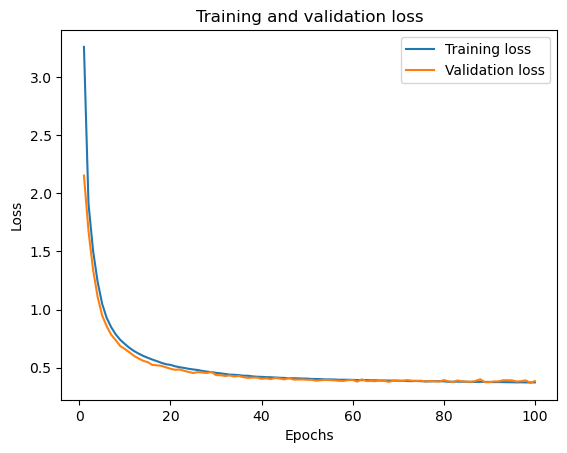

In [26]:
train_loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(train_loss) + 1)

plt.plot(epochs, train_loss, label='Training loss')
plt.plot(epochs, val_loss, label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [27]:
actual_label = train_target["activity"]
multi_input_prediction(prefix_dfg_model_2,train_prefix_trace_encoded, train_dfg_probability, label_encoder)

328/328 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step


array(['permit submitted by employee',
       'permit approved by administration',
       'permit final_approved by supervisor', ..., 'request payment',
       'payment handled', 'zos'], dtype=object)

In [28]:
actual_label = test_target["activity"]
multi_input_prediction(prefix_dfg_model_2,test_prefix_trace_encoded, test_dfg_probability, label_encoder)

199/199 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


array(['permit submitted by employee',
       'permit approved by administration',
       'permit final_approved by supervisor', ..., 'request payment',
       'payment handled', 'zos'], dtype=object)

In [29]:
#save model
prefix_dfg_model_2.save("ptc_prefix_dfg_model_2.keras")

## Prefix_DFG Model_3

In [30]:
#dfg input layer
dfg_features = train_dfg_probability.shape[1]
dfg_input = Input(shape=(dfg_features,),name="dfg")
dfg_layer = Dense(100, activation="relu", name="dfg_layer")(dfg_input)

#prefix layer
prefix_features = train_prefix_trace_encoded.shape[1]
prefix_sequence = train_prefix_trace_encoded.shape[2]
prefix_input = Input(shape=(prefix_features,prefix_sequence),name="prefix")
prefix_layer = LSTM(20, return_sequences=False, name="prefix_dfg_layer")(prefix_input)

# combine dfg with prefix input
combined_input = Concatenate(name="prefix_dfg_input")([dfg_input,prefix_layer])

# Output layer (classification)
output = train_target_encoded.shape[1]
output_layer = Dense(output,activation='softmax')(combined_input)

#Define model
prefix_dfg_model_3 = Model(inputs=[dfg_input,prefix_input],outputs=output_layer)
prefix_dfg_model_3.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['categorical_accuracy'])
prefix_dfg_model_3.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ prefix (InputLayer) │ (None, 22, 31)    │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dfg (InputLayer)    │ (None, 31)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ prefix_dfg_layer    │ (None, 20)        │      4,160 │ prefix[0][0]      │
│ (LSTM)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ prefix_dfg_input    │ (None, 51)        │          0 │ dfg[0][0],        │
│ (Concatenate)       │                   │            │ prefix_dfg_layer… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 31)        │      1,612 │ prefix_dfg_input… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,772 (22.55 KB)

 Trainable params: 5,772 (22.55 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
history = prefix_dfg_model_3.fit([train_dfg_probability,train_prefix_trace_encoded], train_target_encoded, epochs=200, batch_size=100, 
                                 validation_data = ([val_dfg_probability,val_prefix_trace_encoded], val_target_encoded), verbose=0)

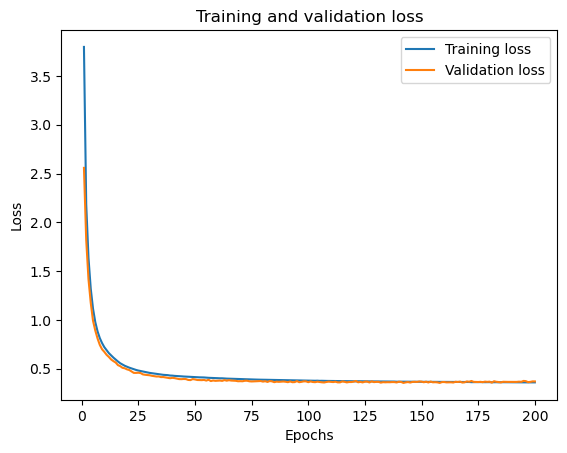

In [32]:
train_loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(train_loss) + 1)

plt.plot(epochs, train_loss, label='Training loss')
plt.plot(epochs, val_loss, label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [33]:
actual_label = train_target["activity"]
multi_input_prediction(prefix_dfg_model_3, train_dfg_probability,train_prefix_trace_encoded, label_encoder)

328/328 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step


array(['permit submitted by employee',
       'permit approved by administration',
       'permit final_approved by supervisor', ..., 'request payment',
       'payment handled', 'zos'], dtype=object)

In [34]:
actual_label = test_target["activity"]
multi_input_prediction(prefix_dfg_model_3,test_dfg_probability, test_prefix_trace_encoded, label_encoder)

199/199 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


array(['permit submitted by employee',
       'permit approved by administration',
       'permit final_approved by supervisor', ..., 'request payment',
       'payment handled', 'zos'], dtype=object)

In [35]:
#save model
prefix_dfg_model_3.save("ptc_prefix_dfg_model_3.keras")